# 02 - Segmentation Analysis

Loads the trained U-Net checkpoints (produced by `scripts/train.py`) and reports real evaluation metrics + training curves. If a checkpoint is missing, the corresponding section is skipped with an explicit message rather than fabricating numbers.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('..'))
from pathlib import Path
import matplotlib.pyplot as plt
import torch

from src.data.dataset import RoofDataset, roof_collate_fn
from src.data.label_maps import segment_classes_with_background, SUPERSTRUCTURE_CLASSES
from src.data.splits import load_splits
from src.data.transforms import build_eval_transforms
from src.evaluation.evaluator import evaluate_model
from src.evaluation.curves import plot_training_curves
from src.models.factory import build_model
from src.training.trainer import load_checkpoint
from src.utils.config import load_config
from src.utils.device import get_device
from src.visualization.plotting import plot_confusion_matrix

from torch.utils.data import DataLoader

cfg = load_config('../configs/unet.yaml')
device = get_device()
splits = load_splits('../data/splits')
eval_tf = build_eval_transforms(cfg.dataset.image_size)
test_dataset = RoofDataset('../data/processed/synthetic', splits['test'], transform=eval_tf, segment_scheme=cfg.dataset.segment_scheme)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=roof_collate_fn)
print(f'Test samples: {len(test_dataset)}')

Test samples: 18


## Roof-segment model

In [2]:
seg_ckpt = Path('../models/unet_segment_best.pt')
seg_classes = segment_classes_with_background(cfg.dataset.segment_scheme)
if seg_ckpt.exists():
    cfg.model['num_classes'] = len(seg_classes)
    seg_model = build_model(cfg)
    info = load_checkpoint(seg_model, seg_ckpt, device=device)
    print(f"Loaded checkpoint from epoch {info['epoch']}, val mIoU={info['val_summary']['mean_iou']:.4f}")
    metrics = evaluate_model(seg_model, test_loader, len(seg_classes), seg_classes, mask_key='segment_mask', device=device)
    print(json.dumps(metrics['overall'], indent=2))
else:
    print('No segment checkpoint found -- run scripts/train.py first. Skipping.')
    metrics = None

Loaded checkpoint from epoch 3, val mIoU=0.1278


{
  "mean_iou": 0.12807986822280398,
  "mean_dice": 0.1501398847197898,
  "mean_precision": 0.2216694093741626,
  "mean_recall": 0.2006358949843529,
  "pixel_accuracy": 0.8193427191840278
}


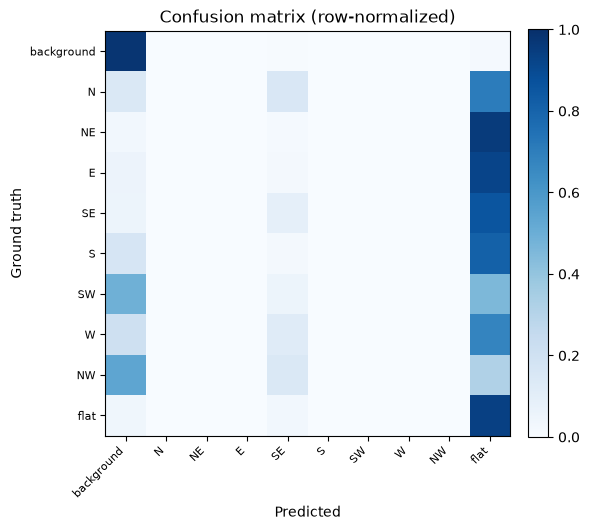

In [3]:
if metrics is not None:
    fig = plot_confusion_matrix(metrics['confusion_matrix'], seg_classes)
    plt.show()

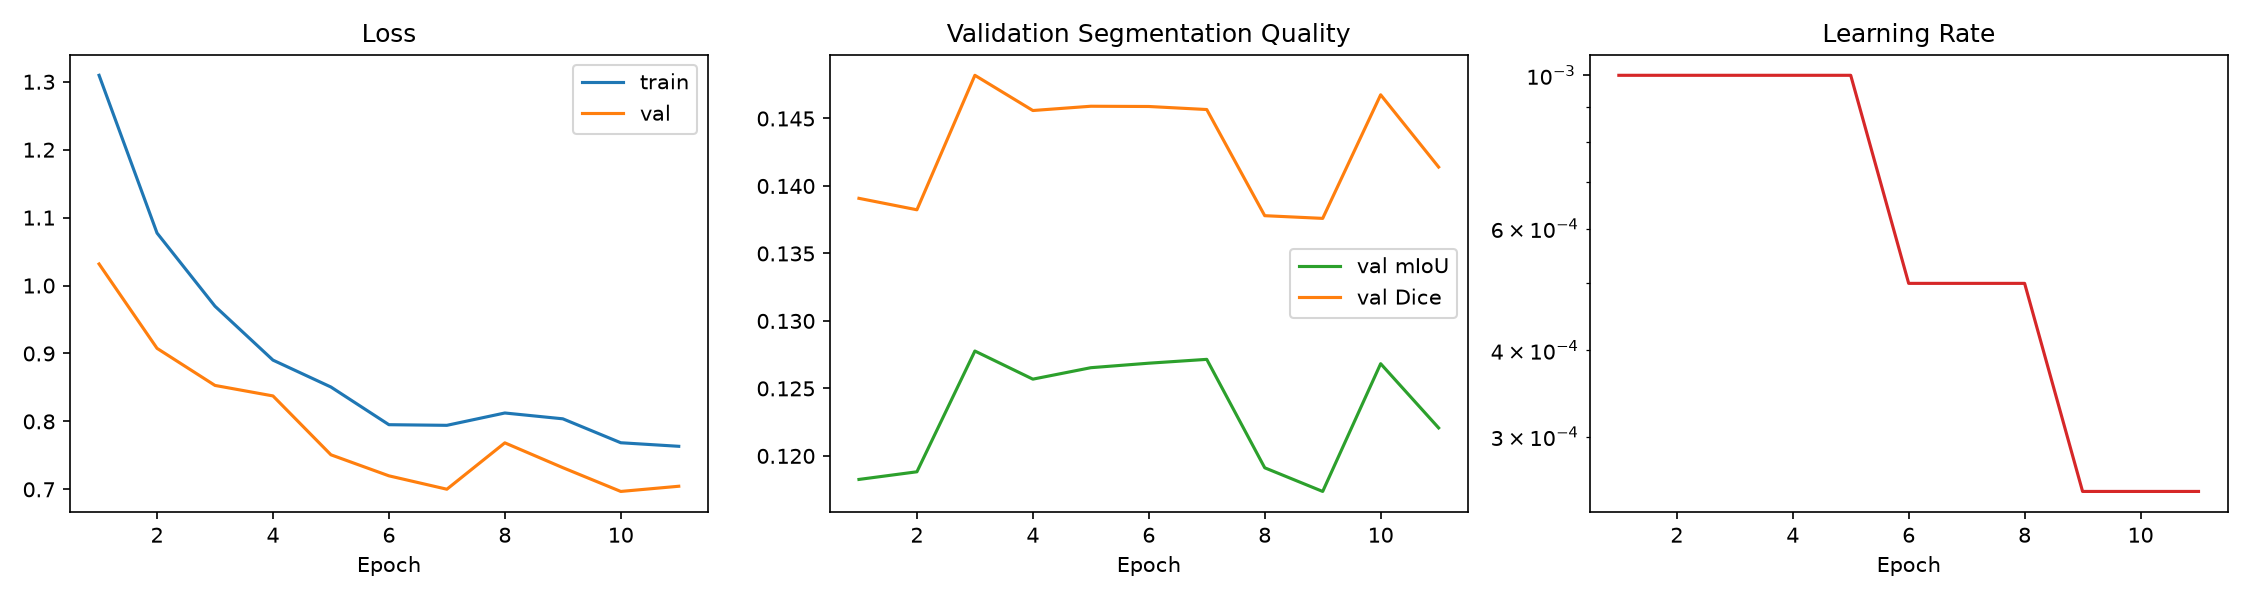

In [4]:
history_path = Path('../models/unet_segment_best_history.json')
if history_path.exists():
    plot_training_curves(history_path, '../results/figures/unet_segment_training_curves.png')
    from PIL import Image
    display(Image.open('../results/figures/unet_segment_training_curves.png'))
else:
    print('No training history found for the segment model yet.')

## Superstructure (obstacle) model

In [5]:
obs_ckpt = Path('../models/unet_superstructure_best.pt')
if obs_ckpt.exists():
    cfg2 = load_config('../configs/unet.yaml')
    cfg2.model['num_classes'] = len(SUPERSTRUCTURE_CLASSES)
    obs_model = build_model(cfg2)
    info2 = load_checkpoint(obs_model, obs_ckpt, device=device)
    print(f"Loaded checkpoint from epoch {info2['epoch']}, val mIoU={info2['val_summary']['mean_iou']:.4f}")
    obs_metrics = evaluate_model(obs_model, test_loader, len(SUPERSTRUCTURE_CLASSES), SUPERSTRUCTURE_CLASSES, mask_key='superstructure_mask', device=device)
    print(json.dumps(obs_metrics['overall'], indent=2))
else:
    print('No superstructure checkpoint found -- run scripts/train.py --task superstructure first.')
    obs_metrics = None

Loaded checkpoint from epoch 28, val mIoU=0.7300


{
  "mean_iou": 0.7298783309905268,
  "mean_dice": 0.7396279097565429,
  "mean_precision": 0.9819962031020141,
  "mean_recall": 0.742957052166284,
  "pixel_accuracy": 0.9965252346462674
}


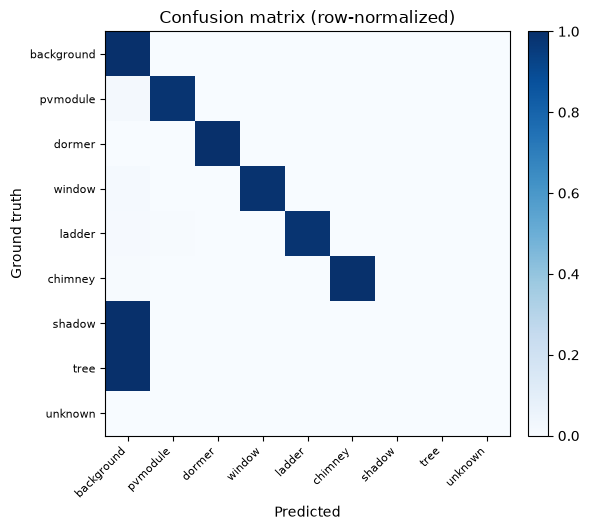

In [6]:
if obs_metrics is not None:
    fig = plot_confusion_matrix(obs_metrics['confusion_matrix'], SUPERSTRUCTURE_CLASSES)
    plt.show()